# ViewCastLK — Exploratory Data Analysis

**What can be known about a Sri Lankan YouTube video before it is published,
and how much of its first-week viewership does that explain?**

This notebook answers that question and hands the answer to feature
engineering. It is not a data-quality report — `dataset_statistics.txt` covers
that. Here we look for *patterns*.

---

## The methodological spine

One fact governs every analysis below:

> **Channel identity explains ~64% of the variance in log day-7 views.
> Everything else combined explains far less.**

That single fact invalidates the obvious way of doing this. If you group by
category and compare means, you are mostly comparing *which channels post in
which category*, not the effect of category. We show this concretely in §4,
where the raw category ranking **inverts** once channel is controlled for.

So the rule throughout:

| question | method |
|---|---|
| "does X matter?" | compare on **within-channel residuals** |
| "how big is the effect?" | report both raw and residual, and say when they disagree |
| "is it real?" | report cell counts and standard errors, not just means |

A **within-channel residual** is `log1p(views)` minus that channel's own mean
`log1p(views)`. It asks: *given this channel, did this video do better or worse
than that channel usually does?* That is the only version of the question a
pre-publication model can actually act on, because the channel is fixed at
prediction time.

## Target

`log1p(day-7 views)`. The raw target has a mean 16x its median and a maximum
four orders of magnitude above it; on the log scale skew is -0.09, near
symmetric. Day 7 is the primary horizon because it has the most labels
(30,718); §11 checks whether the findings hold at 14, 21 and 30 days.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

mpl.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": .25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10,
})

from paths import dataset_path
DATA = dataset_path()
FIGS = Path("eda_figures"); FIGS.mkdir(exist_ok=True)

def save(name):
    plt.tight_layout(); plt.savefig(FIGS / f"{name}.png", bbox_inches="tight")

HORIZON = 7

## 1. Scope and preparation

We keep **eligible** videos (live broadcasts and unparseable durations removed)
that have a **usable** day-7 label — an observation within 12 hours of the
168-hour mark. Anything else is not an observation of day-7 viewership.

`channel_resid` is added here and used for the rest of the notebook.

In [2]:
df = pd.read_parquet(DATA)

d = df[df.eligible & df[f"d{HORIZON}_usable"]].copy()
d["y"] = np.log1p(d[f"d{HORIZON}_views"])

# Within-channel residual: how this video did relative to its own channel.
ch_mean = d.groupby("channel_id").y.transform("mean")
ch_n    = d.groupby("channel_id").y.transform("size")
d["channel_resid"] = d.y - ch_mean
d["channel_n"] = ch_n

print(f"videos with a usable day-{HORIZON} label : {len(d):,}")
print(f"distinct channels                       : {d.channel_id.nunique():,}")
print(f"published                               : "
      f"{d.published_at.min():%Y-%m-%d} to {d.published_at.max():%Y-%m-%d}")
print(f"\nlog1p(views): mean {d.y.mean():.2f}, sd {d.y.std():.2f}, "
      f"skew {d.y.skew():.2f}")
print(f"raw views   : median {d[f'd{HORIZON}_views'].median():,.0f}, "
      f"mean {d[f'd{HORIZON}_views'].mean():,.0f}, "
      f"max {d[f'd{HORIZON}_views'].max():,.0f}")

videos with a usable day-7 label : 30,718
distinct channels                       : 1,944
published                               : 2026-07-16 to 2026-08-11

log1p(views): mean 6.97, sd 2.56, skew -0.09
raw views   : median 1,120, mean 18,338, max 17,366,520


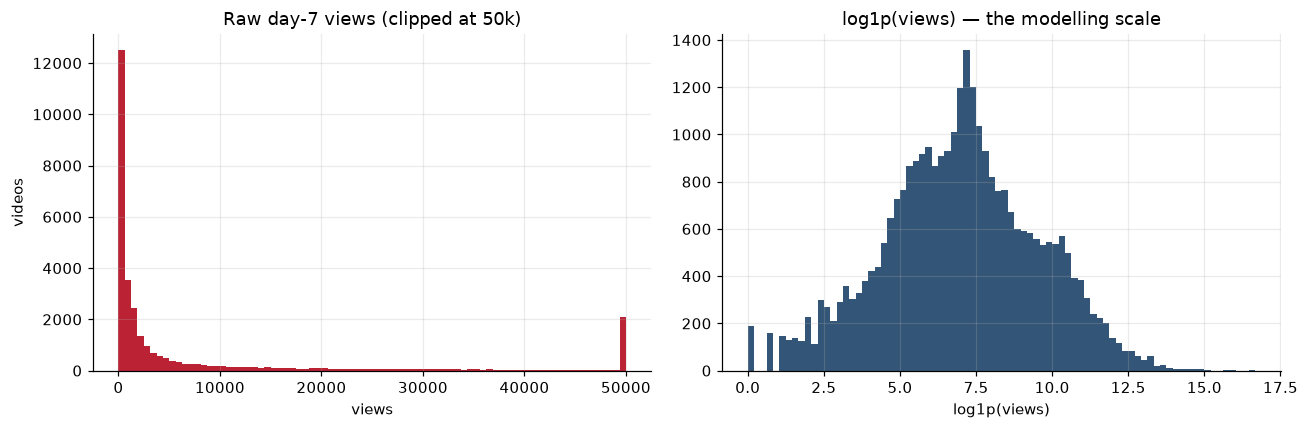

share of all day-7 views held by the top:
    0.1% of videos :  17.1%
    1.0% of videos :  42.7%
    5.0% of videos :  70.8%
   10.0% of videos :  83.3%


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(d[f"d{HORIZON}_views"].clip(upper=50_000), bins=80, color="#b23")
ax[0].set(title=f"Raw day-{HORIZON} views (clipped at 50k)", xlabel="views",
          ylabel="videos")
ax[1].hist(d.y, bins=80, color="#357")
ax[1].set(title="log1p(views) — the modelling scale", xlabel="log1p(views)")
save("01_target_distribution"); plt.show()

q = d[f"d{HORIZON}_views"]
print("share of all day-7 views held by the top:")
for k in (0.001, 0.01, 0.05, 0.10):
    print(f"  {k:>6.1%} of videos : {q.nlargest(int(len(q)*k)).sum()/q.sum():>6.1%}")

## 2. Variance decomposition — how much can anything explain?

For a grouping *g*, the share of variance its group means explain is

$$R^2_g = 1 - \frac{\mathrm{Var}(y - \bar{y}_g)}{\mathrm{Var}(y)}$$

This is an **upper bound** on what a model using only that variable could
achieve — it assumes you predict each group's mean perfectly.

Read the result as a budget: it tells you where predictive power can possibly
come from, before any modelling.

In [4]:
def var_explained(frame, col, target="y"):
    g = frame.groupby(col)[target].transform("mean")
    return 1 - (frame[target] - g).var() / frame[target].var()

d["subs_band"] = pd.cut(d.ch_subs_at_publish,
                        [0, 1e3, 1e4, 1e5, 1e6, np.inf],
                        labels=["<1K", "1K-10K", "10K-100K", "100K-1M", "1M+"])
d["dur_band"] = pd.cut(d.duration_seconds,
                       [0, 60, 180, 600, 1800, np.inf],
                       labels=["<=60s", "1-3m", "3-10m", "10-30m", "30m+"])

rows = []
for col in ["channel_id", "category_name", "subs_band", "dur_band",
            "publish_hour_slt", "publish_dow_slt", "title_script",
            "is_short", "definition", "made_for_kids", "default_audio_language",
            "publish_is_weekend", "channel_country"]:
    sub = d[d[col].notna()] if d[col].isna().any() else d
    rows.append({"variable": col, "levels": sub[col].nunique(),
                 "var_explained": var_explained(sub, col)})

vd = pd.DataFrame(rows).sort_values("var_explained", ascending=False)
vd["var_explained"] = vd.var_explained.round(4)
print(vd.to_string(index=False))

              variable  levels  var_explained
            channel_id    1944          0.641
             subs_band       5          0.198
         category_name      14          0.079
          title_script       4          0.034
default_audio_language      32          0.026
              dur_band       5          0.019
      publish_hour_slt      24          0.018
            definition       2          0.004
         made_for_kids       2          0.003
       publish_dow_slt       7          0.000
              is_short       2          0.000
       channel_country       3          0.000
    publish_is_weekend       2          0.000


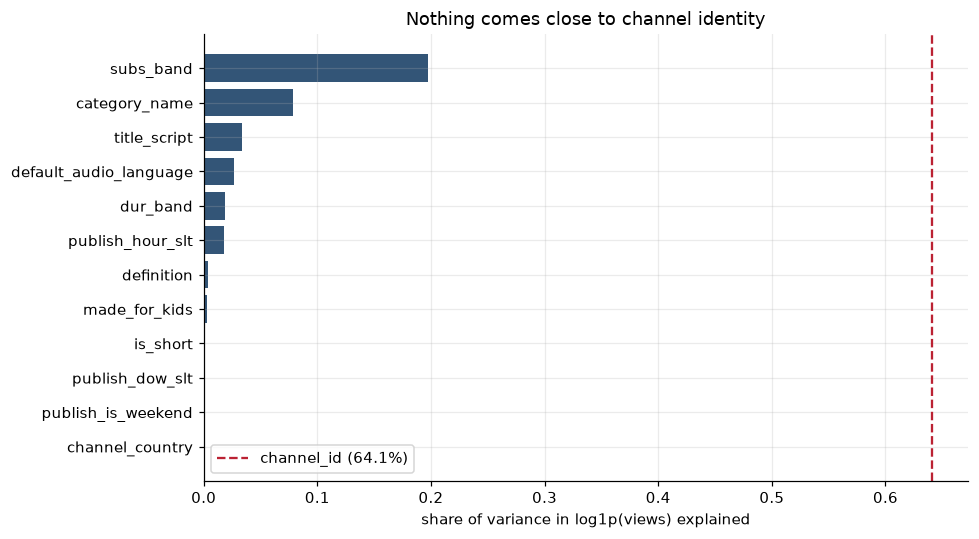

In [5]:
plot = vd[vd.variable != "channel_id"].sort_values("var_explained")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot.variable, plot.var_explained, color="#357")
ax.axvline(vd.loc[vd.variable == "channel_id", "var_explained"].iloc[0],
           color="#b23", ls="--",
           label=f"channel_id ({vd.loc[vd.variable=='channel_id','var_explained'].iloc[0]:.1%})")
ax.set(xlabel="share of variance in log1p(views) explained",
       title="Nothing comes close to channel identity")
ax.legend()
save("02_variance_explained"); plt.show()

### Reading this

`channel_id` has thousands of levels, so some of its apparent power is
overfitting — with enough groups you can explain anything. The honest
comparison is against a *permuted* channel label, which we do next.

Everything below `channel_id` is measured on few levels and is not inflated
this way.

In [6]:
rng = np.random.default_rng(0)
real = var_explained(d, "channel_id")
perm = []
for _ in range(5):
    tmp = d.copy()
    tmp["fake"] = rng.permutation(tmp.channel_id.values)
    perm.append(var_explained(tmp, "fake"))

print(f"channel_id, real        : {real:.4f}")
print(f"channel_id, shuffled    : {np.mean(perm):.4f}  "
      f"(this is the overfitting floor)")
print(f"genuine channel effect  : {real - np.mean(perm):.4f}")
print("\nSo channel identity really does carry most of the signal; the")
print("shuffled baseline shows only a small part is an artefact of group count.")

channel_id, real        : 0.6406
channel_id, shuffled    : 0.0627  (this is the overfitting floor)
genuine channel effect  : 0.5779

So channel identity really does carry most of the signal; the
shuffled baseline shows only a small part is an artefact of group count.


## 3. What is it about a channel that matters?

Channel identity dominates — but *identity* is not a usable feature for a new
channel. What measurable channel properties stand in for it?

In [7]:
ch = (d.groupby("channel_id")
        .agg(videos=("y", "size"), mean_y=("y", "mean"),
             subs=("ch_subs_at_publish", "median"),
             ch_age=("channel_age_days_at_publish", "median"),
             shorts=("is_short", "mean"),
             dur=("duration_seconds", "median"),
             cats=("category_name", "nunique"))
        .reset_index())
ch["posts_per_day"] = ch.videos / d.published_at.dt.date.nunique()
ch["log_subs"] = np.log1p(ch.subs)

print(f"channels: {len(ch):,}")
print(ch[["videos","subs","posts_per_day","mean_y"]].describe(
    percentiles=[.5, .9, .99]).to_string())

channels: 1,944
         videos           subs  posts_per_day    mean_y
count 1,944.000      1,944.000      1,944.000 1,944.000
mean     15.801    124,995.182          0.585     6.144
std     110.385    498,706.009          4.088     2.362
min       1.000          0.000          0.037     0.000
50%       4.000      9,345.000          0.148     6.150
90%      22.000    196,700.000          0.815     9.139
99%     115.000  1,921,400.000          4.259    11.724
max   3,659.000 10,950,000.000        135.519    15.641


Spearman correlation with channel mean log-views:

log_subs         0.607
posts_per_day    0.188
videos           0.188
ch_age           0.068
dur              0.035
shorts           0.026
cats            -0.011


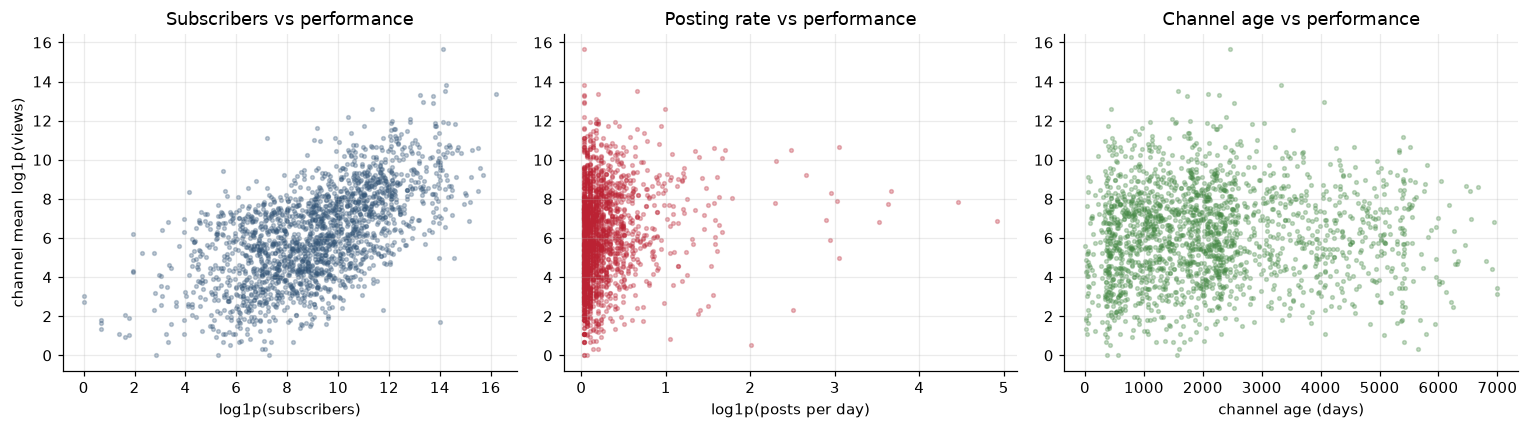

In [8]:
num = ["log_subs", "posts_per_day", "ch_age", "shorts", "dur", "cats", "videos"]
corr = ch[num + ["mean_y"]].corr(method="spearman")["mean_y"].drop("mean_y")
print("Spearman correlation with channel mean log-views:\n")
print(corr.sort_values(ascending=False).to_string())

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].scatter(ch.log_subs, ch.mean_y, s=6, alpha=.3, color="#357")
ax[0].set(xlabel="log1p(subscribers)", ylabel="channel mean log1p(views)",
          title="Subscribers vs performance")
ax[1].scatter(np.log1p(ch.posts_per_day), ch.mean_y, s=6, alpha=.3, color="#b23")
ax[1].set(xlabel="log1p(posts per day)", title="Posting rate vs performance")
ax[2].scatter(ch.ch_age, ch.mean_y, s=6, alpha=.3, color="#484")
ax[2].set(xlabel="channel age (days)", title="Channel age vs performance")
save("03_channel_properties"); plt.show()

### The dilution question

The largest channel posts ~150 clips a day. Does flooding the feed cost views
per video? This is testable: hold subscribers roughly constant and vary posting
rate.

In [9]:
band = pd.cut(ch.subs, [0, 1e4, 1e5, 1e6, np.inf],
              labels=["<10K", "10K-100K", "100K-1M", "1M+"])
rate = pd.qcut(ch.posts_per_day, 4, labels=["Q1 slowest", "Q2", "Q3", "Q4 fastest"],
               duplicates="drop")
piv = ch.assign(band=band, rate=rate).pivot_table(
    index="band", columns="rate", values="mean_y", aggfunc="mean", observed=True)
cnt = ch.assign(band=band, rate=rate).pivot_table(
    index="band", columns="rate", values="mean_y", aggfunc="size", observed=True)
print("channel mean log1p(views), by subscriber band x posting rate:\n")
print(piv.round(2).to_string())
print("\ncell counts:\n"); print(cnt.to_string())
print("\nIf posting faster diluted views, rows would fall left-to-right.")

channel mean log1p(views), by subscriber band x posting rate:

rate      Q1 slowest     Q2    Q3  Q4 fastest
band                                         
<10K           4.770  5.010 4.970       5.270
10K-100K       6.500  6.830 6.770       7.210
100K-1M        8.590  8.660 8.540       7.870
1M+            8.490 10.210 9.950       9.270

cell counts:

rate      Q1 slowest   Q2   Q3  Q4 fastest
band                                      
<10K             418  196  211         178
10K-100K         206   97  143         163
100K-1M           62   53   66          81
1M+                8    2   18          40

If posting faster diluted views, rows would fall left-to-right.


## 4. Category — where the raw view is actively misleading

This is the headline methodological result of the notebook.

In [10]:
raw = d.groupby("category_name").y.agg(["size", "mean"])
raw["raw_views"] = np.expm1(raw["mean"])

# Within-channel: only channels that actually post in more than one category
# can contribute -- for a single-category channel the comparison is empty.
multi = d.groupby("channel_id").category_name.nunique()
dm = d[d.channel_id.isin(multi[multi > 1].index)]

within = dm.groupby("category_name").channel_resid.agg(["size", "mean", "std"])
within["se"] = within["std"] / np.sqrt(within["size"])
within["ci95"] = 1.96 * within.se

cmp = raw[["size", "raw_views", "mean"]].join(
    within[["size", "mean", "ci95"]], lsuffix="_raw", rsuffix="_within")
cmp.columns = ["n_raw", "raw_views", "raw_logmean", "n_within",
               "within_effect", "ci95"]
cmp["raw_rank"] = cmp.raw_logmean.rank(ascending=False).astype(int)
cmp["within_rank"] = cmp.within_effect.rank(ascending=False).astype(int)
cmp["rank_shift"] = cmp.raw_rank - cmp.within_rank
print(cmp.sort_values("raw_rank").to_string())

                      n_raw  raw_views  raw_logmean  n_within  within_effect  ci95  raw_rank  within_rank  rank_shift
category_name                                                                                                        
Entertainment          4006  4,801.490        8.477       260         -0.321 0.165         1           13         -12
Comedy                  667  3,658.987        8.205        68          0.125 0.307         2            4          -2
People & Blogs         1849  1,838.317        7.517       910         -0.045 0.099         3            8          -5
Sports                  730    970.330        6.879        12         -0.469 1.167         4           14         -10
News & Politics       10242    960.322        6.868        62          1.985 0.376         5            1           4
Education              4200    916.000        6.821       244          0.050 0.136         6            6           0
Music                  2058    901.418        6.805     

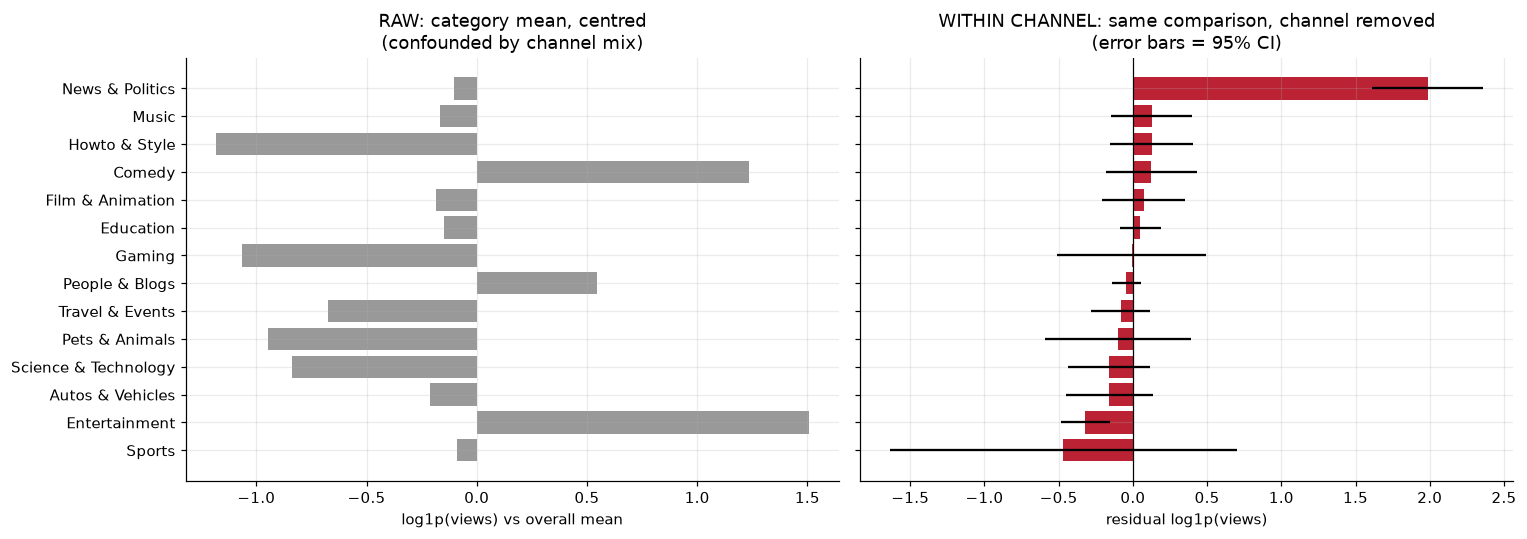

Categories whose rank moves most when channel is controlled:
                raw_rank  within_rank  rank_shift  n_within
category_name                                              
Entertainment          1           13         -12       260
Howto & Style         14            3          11        82
Sports                 4           14         -10        12
Gaming                13            7           6        64
Music                  7            2           5        94
People & Blogs         3            8          -5       910


In [11]:
o = cmp.sort_values("within_effect")
fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
ax[0].barh(o.index, o.raw_logmean - d.y.mean(), color="#999")
ax[0].set(title="RAW: category mean, centred\n(confounded by channel mix)",
          xlabel="log1p(views) vs overall mean")
ax[1].barh(o.index, o.within_effect, xerr=o.ci95, color="#b23")
ax[1].axvline(0, color="k", lw=.8)
ax[1].set(title="WITHIN CHANNEL: same comparison, channel removed\n"
                "(error bars = 95% CI)", xlabel="residual log1p(views)")
save("04_category_raw_vs_within"); plt.show()

print("Categories whose rank moves most when channel is controlled:")
print(cmp.reindex(cmp.rank_shift.abs().sort_values(ascending=False).index)
        [["raw_rank","within_rank","rank_shift","n_within"]].head(6).to_string())

### Caveat, stated plainly

The within-channel column rests only on channels that post across multiple
categories. Those channels may be unusual, and some cells are small — read the
confidence intervals and the `n_within` column before believing any single row.

Where `n_within` is small, the raw and within numbers disagreeing tells you the
category is **channel-bound** (only certain channels post it), which is itself
a finding: for those categories, category and channel are the same variable.

## 5. Timing — is there a best hour to publish?

The most commercially interesting question, and the most confounded: news
channels post on fixed schedules, so a raw hourly profile largely traces
*who* posts when.

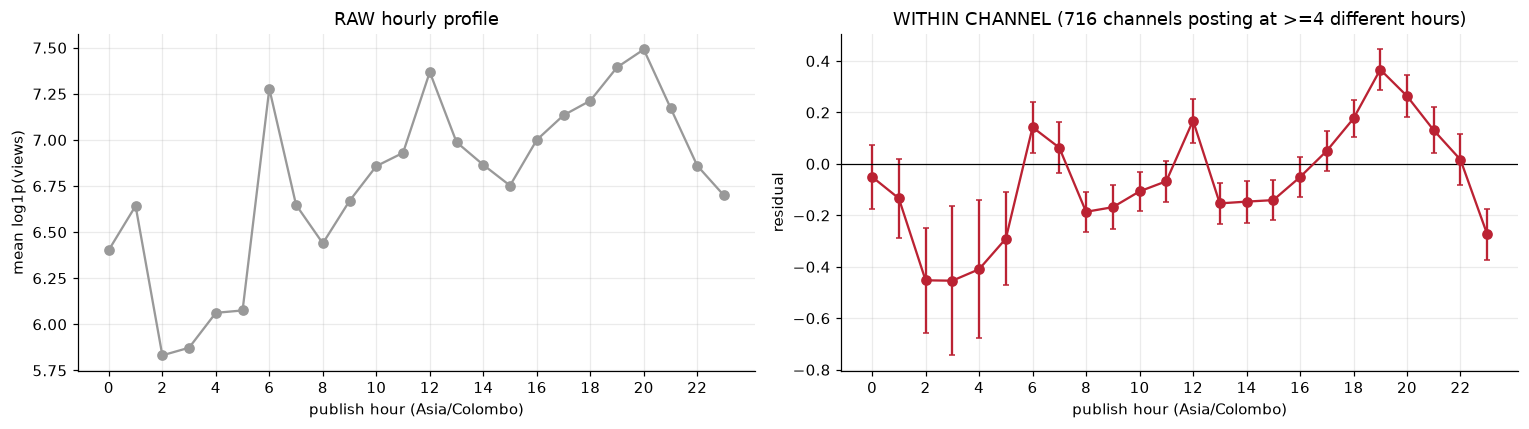

raw spread    (best-worst hour): 1.659 log units
within spread (best-worst hour): 0.821 log units
best hours within channel : [19, 20, 18]
worst hours within channel: [3, 2, 4]


In [12]:
by_hour_raw = d.groupby("publish_hour_slt").y.agg(["size", "mean"])

# Only channels that publish across several hours can inform an hour effect.
hspread = d.groupby("channel_id").publish_hour_slt.nunique()
dh = d[d.channel_id.isin(hspread[hspread >= 4].index)]
by_hour_within = dh.groupby("publish_hour_slt").channel_resid.agg(
    ["size", "mean", "std"])
by_hour_within["se"] = by_hour_within["std"] / np.sqrt(by_hour_within["size"])

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(by_hour_raw.index, by_hour_raw["mean"], marker="o", color="#999")
ax[0].set(title="RAW hourly profile", xlabel="publish hour (Asia/Colombo)",
          ylabel="mean log1p(views)", xticks=range(0, 24, 2))
ax[1].errorbar(by_hour_within.index, by_hour_within["mean"],
               yerr=1.96*by_hour_within.se, marker="o", color="#b23", capsize=2)
ax[1].axhline(0, color="k", lw=.8)
ax[1].set(title=f"WITHIN CHANNEL ({dh.channel_id.nunique():,} channels "
                f"posting at >=4 different hours)",
          xlabel="publish hour (Asia/Colombo)", ylabel="residual",
          xticks=range(0, 24, 2))
save("05_publish_hour"); plt.show()

sw = by_hour_within["mean"]
print(f"raw spread    (best-worst hour): {by_hour_raw['mean'].max()-by_hour_raw['mean'].min():.3f} log units")
print(f"within spread (best-worst hour): {sw.max()-sw.min():.3f} log units")
print(f"best hours within channel : {list(sw.nlargest(3).index)}")
print(f"worst hours within channel: {list(sw.nsmallest(3).index)}")

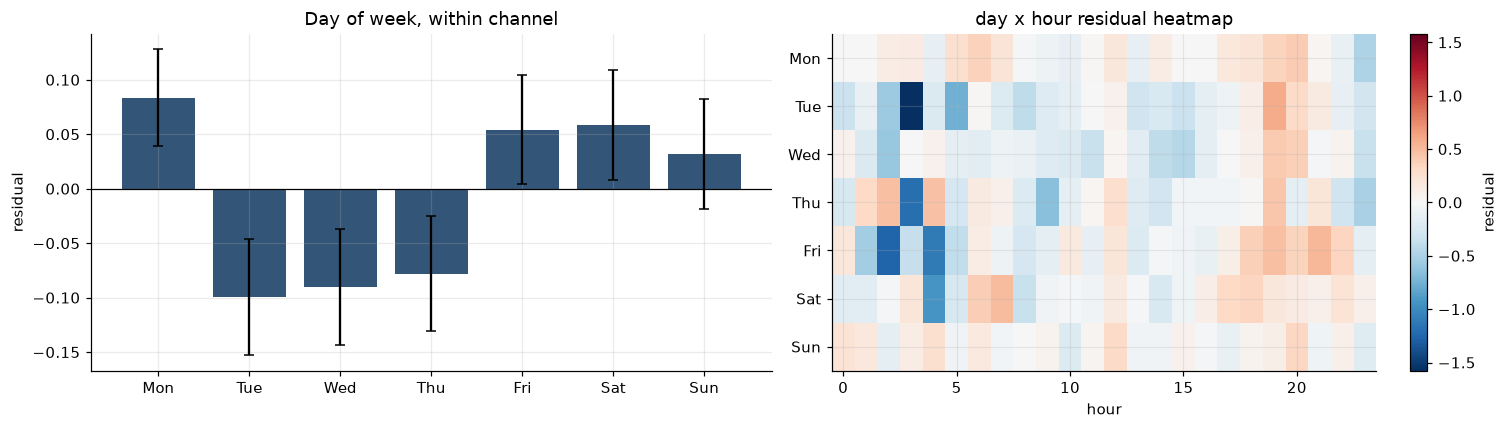

In [13]:
# Day of week, and the hour x weekend interaction.
dow = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
w = dh.groupby("publish_dow_slt").channel_resid.agg(["size","mean","std"])
w["se"] = w["std"]/np.sqrt(w["size"])
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar([dow[i] for i in w.index], w["mean"], yerr=1.96*w.se,
          color="#357", capsize=3)
ax[0].axhline(0, color="k", lw=.8); ax[0].set(title="Day of week, within channel",
                                              ylabel="residual")

hm = dh.pivot_table(index="publish_dow_slt", columns="publish_hour_slt",
                    values="channel_resid", aggfunc="mean")
im = ax[1].imshow(hm.values, aspect="auto", cmap="RdBu_r",
                  vmin=-np.abs(hm.values).max(), vmax=np.abs(hm.values).max())
ax[1].set(title="day x hour residual heatmap", xlabel="hour",
          yticks=range(7), yticklabels=dow)
plt.colorbar(im, ax=ax[1], label="residual")
save("06_dow_and_heatmap"); plt.show()

## 6. Duration and format

Shorts vs long-form is the most consequential format decision a creator makes.
Raw medians are nearly identical, which is suspicious — it usually means two
opposing effects cancelling.

RAW:
              n    median       mean
is_short                            
False     18953   981.000 13,630.244
True      11765 1,255.000 25,922.108

WITHIN CHANNEL (627 channels posting both):
              n   mean    sd
is_short                    
False     14290 -0.021 1.735
True       8084  0.036 1.496


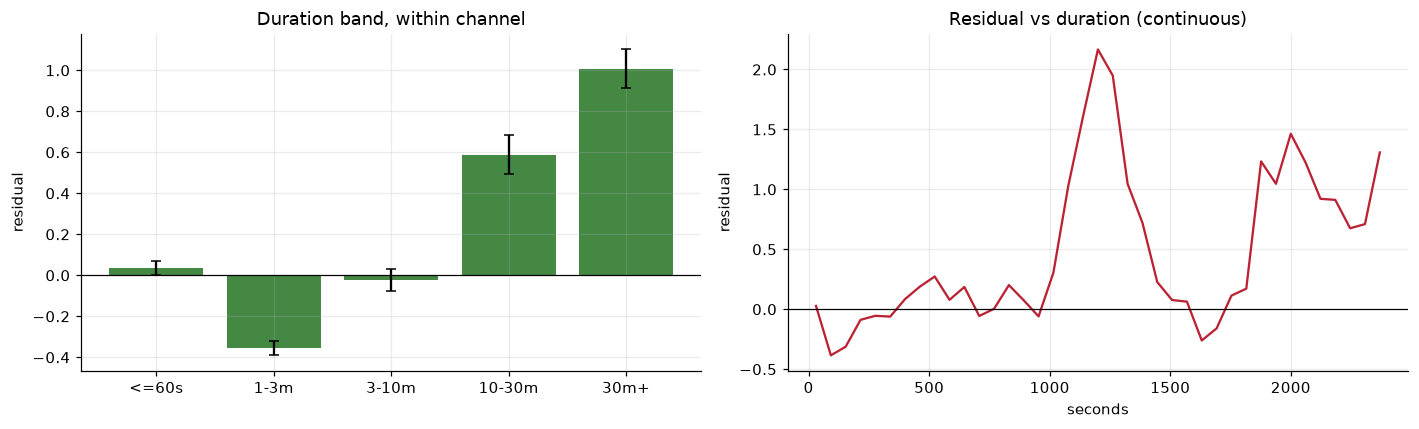

In [14]:
print("RAW:")
print(d.groupby("is_short")[f"d{HORIZON}_views"].agg(
    n="size", median="median", mean="mean").to_string())

fmt = d.groupby("channel_id").is_short.nunique()
dfm = d[d.channel_id.isin(fmt[fmt > 1].index)]
print(f"\nWITHIN CHANNEL ({dfm.channel_id.nunique():,} channels posting both):")
print(dfm.groupby("is_short").channel_resid.agg(
    n="size", mean="mean", sd="std").to_string())

t = dfm.groupby("dur_band", observed=True).channel_resid.agg(["size","mean","std"])
t["se"] = t["std"]/np.sqrt(t["size"])
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(t.index.astype(str), t["mean"], yerr=1.96*t.se, color="#484", capsize=3)
ax[0].axhline(0, color="k", lw=.8)
ax[0].set(title="Duration band, within channel", ylabel="residual")

s = dfm[dfm.duration_seconds < 2400]
bins = np.linspace(0, 2400, 40)
mids = (bins[:-1]+bins[1:])/2
prof = s.groupby(pd.cut(s.duration_seconds, bins),
                 observed=True).channel_resid.mean()
ax[1].plot(mids[:len(prof)], prof.values, color="#b23")
ax[1].axhline(0, color="k", lw=.8)
ax[1].set(title="Residual vs duration (continuous)", xlabel="seconds",
          ylabel="residual")
save("07_duration"); plt.show()

## 7. Title features

Everything here is knowable before publication and is cheap to act on, so even
small effects are practically useful — a creator can rewrite a title.

In [15]:
title_feats = ["title_length", "title_word_count", "title_upper_ratio",
               "tag_count", "description_length"]
flags = ["title_has_number", "title_has_question", "title_has_exclaim",
         "caption", "made_for_kids"]

print("Spearman correlation with WITHIN-CHANNEL residual:\n")
print(d[title_feats + ["channel_resid"]].corr(method="spearman")
        ["channel_resid"].drop("channel_resid").sort_values(
            key=abs, ascending=False).to_string())

print("\nBinary flags — mean residual by value:\n")
for f in flags:
    if d[f].notna().any():
        g = d.groupby(f).channel_resid.agg(["size", "mean"])
        if len(g) == 2:
            diff = g["mean"].iloc[1] - g["mean"].iloc[0]
            print(f"  {f:22} effect {diff:+.3f}   "
                  f"(n={g['size'].iloc[1]:,} true / {g['size'].iloc[0]:,} false)")

Spearman correlation with WITHIN-CHANNEL residual:

title_upper_ratio     0.077
title_word_count      0.027
description_length    0.019
title_length          0.014
tag_count            -0.010

Binary flags — mean residual by value:

  title_has_number       effect +0.256   (n=9,559 true / 21,159 false)
  title_has_question     effect -0.184   (n=1,838 true / 28,880 false)
  title_has_exclaim      effect -0.192   (n=2,049 true / 28,669 false)
  caption                effect +0.044   (n=65 true / 30,653 false)
  made_for_kids          effect -0.248   (n=108 true / 30,610 false)


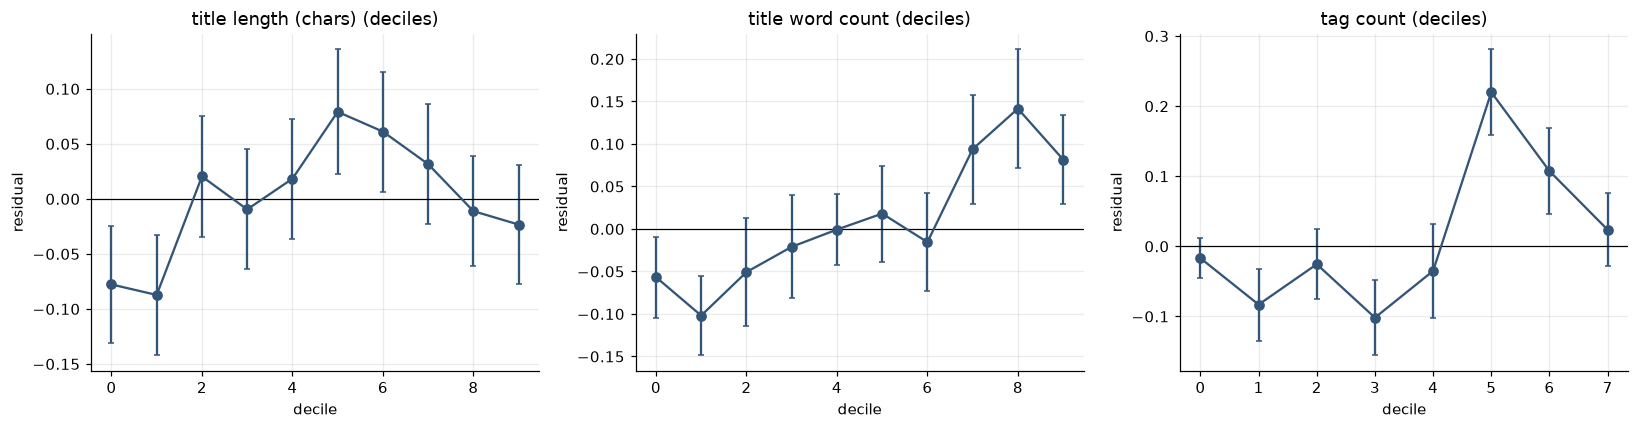

title_script, within channel (channels using >1 script):
                    n   mean
title_script                
latin_script     3267 -0.023
mixed_script        8  0.584
sinhala_script  14906  0.005
tamil_script      343  0.002


In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, f, lab in zip(ax, ["title_length", "title_word_count", "tag_count"],
                     ["title length (chars)", "title word count", "tag count"]):
    b = pd.qcut(d[f], 10, duplicates="drop")
    g = d.groupby(b, observed=True).channel_resid.agg(["mean", "size", "std"])
    g["se"] = g["std"]/np.sqrt(g["size"])
    a.errorbar(range(len(g)), g["mean"], yerr=1.96*g.se, marker="o",
               color="#357", capsize=2)
    a.axhline(0, color="k", lw=.8)
    a.set(title=f"{lab} (deciles)", xlabel="decile", ylabel="residual")
save("08_title_features"); plt.show()

# Script is largely an audience-size proxy; check it within channel too.
sc = d.groupby("channel_id").title_script.nunique()
ds = d[d.channel_id.isin(sc[sc > 1].index)]
print("title_script, within channel (channels using >1 script):")
print(ds.groupby("title_script").channel_resid.agg(
    n="size", mean="mean").to_string())

## 8. Tag mining

Tags are the richest pre-publication text field. 30% of videos have none —
which is itself a signal worth testing before treating it as missing data.

In [17]:
print("Having ANY tags at all, within channel:")
d["has_tags"] = d.tags.notna()
ht = d.groupby("channel_id").has_tags.nunique()
dt = d[d.channel_id.isin(ht[ht > 1].index)]
print(dt.groupby("has_tags").channel_resid.agg(n="size", mean="mean").to_string())

# Per-tag lift, measured on residuals so a tag cannot win by belonging to a
# large channel.
ex = d[d.tags.notna()][["tags", "channel_resid"]].copy()
ex["tag"] = ex.tags.str.lower().str.split("|")
ex = ex.explode("tag")
ex["tag"] = ex.tag.str.strip()
ex = ex[ex.tag.str.len() > 1]

tg = ex.groupby("tag").channel_resid.agg(["size", "mean", "std"])
tg = tg[tg["size"] >= 100]
tg["se"] = tg["std"]/np.sqrt(tg["size"])
tg["t"] = tg["mean"]/tg.se
print(f"\n{len(tg):,} tags used on >=100 videos\n")
print("STRONGEST POSITIVE (by t-statistic):")
print(tg.nlargest(15, "t")[["size", "mean", "t"]].to_string())
print("\nSTRONGEST NEGATIVE:")
print(tg.nsmallest(15, "t")[["size", "mean", "t"]].to_string())

Having ANY tags at all, within channel:
             n   mean
has_tags             
False     2693  0.069
True      5008 -0.037



505 tags used on >=100 videos

STRONGEST POSITIVE (by t-statistic):
                        size  mean     t
tag                                     
best sinhala teledrama   176 1.301 9.253
sinhala teledrama        563 0.688 8.745
sirasa drama             211 0.668 8.740
drama recap              161 1.304 8.679
sri lanka drama          555 0.696 8.284
new teledrama            308 0.903 8.269
new sinhala teledrama    389 0.753 8.063
උණුසුම් පුවත්            149 1.244 7.813
sirasa live              204 0.618 7.643
best moments             149 1.206 7.587
best scenes              147 1.209 7.506
sinhala drama            730 0.531 7.442
sri lankan drama         396 0.668 7.379
sirasa                   261 0.804 7.088
today episode            266 0.853 6.995

STRONGEST NEGATIVE:
                     size   mean       t
tag                                     
rathu ira             110 -1.751 -12.392
aththasahaboruwaha    272 -0.350  -6.990
hathwenipeya          272 -0.350  -6.990
lankadee

In [18]:
# Association mining: which tag PAIRS co-occur, and do pairs beat their parts?
from itertools import combinations
from collections import Counter

top_tags = set(tg.nlargest(300, "size").index)
sets = (d[d.tags.notna()].tags.str.lower().str.split("|")
          .apply(lambda ts: {t.strip() for t in ts} & top_tags))
pairs = Counter()
for s in sets:
    if 1 < len(s) <= 25:
        pairs.update(combinations(sorted(s), 2))

rows = []
resid = d[d.tags.notna()].channel_resid.values
for (a, b), n in pairs.most_common(400):
    mask = sets.apply(lambda s: a in s and b in s).values
    if mask.sum() >= 50:
        rows.append({"tag_a": a, "tag_b": b, "n": int(mask.sum()),
                     "pair_effect": resid[mask].mean(),
                     "a_alone": tg.loc[a, "mean"] if a in tg.index else np.nan,
                     "b_alone": tg.loc[b, "mean"] if b in tg.index else np.nan})
ar = pd.DataFrame(rows)
if len(ar):
    ar["synergy"] = ar.pair_effect - ar[["a_alone", "b_alone"]].max(axis=1)
    print("Tag pairs that beat either tag alone (positive synergy):\n")
    print(ar.nlargest(12, "synergy").to_string(index=False))
else:
    print("no tag pair reached the support threshold")

Tag pairs that beat either tag alone (positive synergy):

        tag_a              tag_b    n  pair_effect  a_alone  b_alone  synergy
breaking news        sirasa news  913        0.079   -0.055   -0.070    0.134
  sirasa news     sri lanka news 1007        0.071   -0.070   -0.012    0.083
 english news          sri lanka  930        0.077   -0.071    0.013    0.064
  latest news         today news 2387        0.008   -0.060   -0.055    0.063
  derana news        latest news 2318        0.000   -0.063   -0.060    0.060
  latest news         news today 2336        0.006   -0.060   -0.050    0.056
    sri lanka   sri lanka sports  927        0.096    0.013    0.068    0.028
breaking news sri lanka politics  914        0.080   -0.055    0.053    0.027
breaking news          sri lanka 1676        0.037   -0.055    0.013    0.023
    sri lanka sri lanka politics  914        0.075    0.013    0.053    0.022
  sirasa news sri lanka politics 1007        0.071   -0.070    0.053    0.018
    si

## 9. Posting cadence and self-cannibalisation

In §4 the category inversion was explained by a *mechanism*: high-volume news
channels post many near-identical clips a day and split a fixed audience across
them. That was an assertion. This section tests it directly.

The question a creator would ask: **does publishing another video soon after
this one cost it views?**

Two things to be careful about:

* Gaps must be computed over **every** eligible upload by that channel, not
  only the labelled ones. Using labelled videos alone would invent gaps of days
  where the channel actually posted hourly.
* Gap and channel are entangled — fast-posting channels have small gaps by
  definition — so, as everywhere else, the effect is measured on
  **within-channel residuals**.

In [19]:
# Neighbour structure from the FULL eligible set, then joined back to the
# labelled subset. Restricting to labelled videos first would fabricate gaps.
allv = df[df.eligible][["video_id", "channel_id", "published_at"]].copy()
allv = allv.sort_values(["channel_id", "published_at"])

grp = allv.groupby("channel_id").published_at
allv["gap_prev_h"] = grp.diff().dt.total_seconds() / 3600
allv["gap_next_h"] = (grp.shift(-1) - allv.published_at).dt.total_seconds() / 3600

# How crowded is this video's own channel around its publication?
ts = allv.set_index("published_at")
def crowd(g, hours):
    return (g.rolling(f"{hours}h", closed="both").video_id.count() - 1)
allv["same_ch_24h_before"] = (
    ts.groupby("channel_id", group_keys=False)
      .apply(lambda g: crowd(g, 24)).values)

d = d.merge(allv[["video_id", "gap_prev_h", "gap_next_h",
                  "same_ch_24h_before"]], on="video_id", how="left")

print("gap since the channel's previous upload (hours):")
print(d.gap_prev_h.describe(percentiles=[.1, .25, .5, .75, .9]).to_string())
print(f"\nvideos with a previous upload < 1h earlier: "
      f"{(d.gap_prev_h < 1).mean():.1%}")
print(f"same-channel uploads in the 24h before     : "
      f"median {d.same_ch_24h_before.median():.0f}, "
      f"max {d.same_ch_24h_before.max():.0f}")

gap since the channel's previous upload (hours):
count   30,426.000
mean        23.569
std         64.687
min          0.000
10%          0.016
25%          0.138
50%          1.137
75%         21.944
90%         53.630
max        912.502

videos with a previous upload < 1h earlier: 48.1%
same-channel uploads in the 24h before     : median 5, max 207


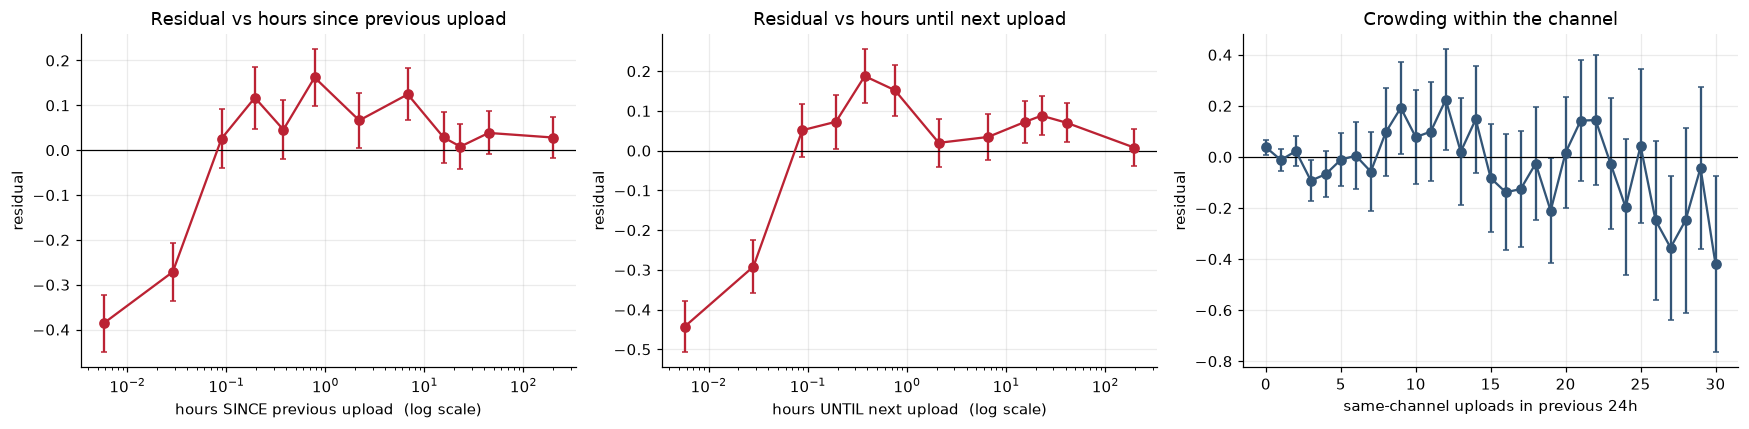

Spearman correlation with within-channel residual:
  gap_prev_h             +0.103   (n=30,426)
  gap_next_h             +0.109   (n=30,067)
  same_ch_24h_before     -0.069   (n=30,718)


In [20]:
# Effect of the gap BEFORE (how long the channel waited) and the gap AFTER
# (how quickly it followed up). The second is the cannibalisation test proper:
# what follows a video cannot have caused its own publication, so a negative
# effect there is harder to explain away as scheduling.
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

for a, col, lab in [(ax[0], "gap_prev_h", "hours SINCE previous upload"),
                    (ax[1], "gap_next_h", "hours UNTIL next upload")]:
    s = d[d[col].between(0, 24 * 14)]
    b = pd.qcut(s[col], 12, duplicates="drop")
    g = s.groupby(b, observed=True).channel_resid.agg(["size", "mean", "std"])
    g["se"] = g["std"] / np.sqrt(g["size"])
    mids = [iv.mid for iv in g.index]
    a.errorbar(mids, g["mean"], yerr=1.96 * g.se, marker="o", capsize=2,
               color="#b23")
    a.axhline(0, color="k", lw=.8); a.set_xscale("log")
    a.set(xlabel=lab + "  (log scale)", ylabel="residual",
          title=f"Residual vs {lab.lower()}")

s = d[d.same_ch_24h_before <= 30]
g = s.groupby("same_ch_24h_before").channel_resid.agg(["size", "mean", "std"])
g = g[g["size"] >= 30]; g["se"] = g["std"] / np.sqrt(g["size"])
ax[2].errorbar(g.index, g["mean"], yerr=1.96 * g.se, marker="o", capsize=2,
               color="#357")
ax[2].axhline(0, color="k", lw=.8)
ax[2].set(xlabel="same-channel uploads in previous 24h", ylabel="residual",
          title="Crowding within the channel")
save("14_cadence"); plt.show()

print("Spearman correlation with within-channel residual:")
for c in ["gap_prev_h", "gap_next_h", "same_ch_24h_before"]:
    s = d[[c, "channel_resid"]].dropna()
    print(f"  {c:22} {s.corr(method='spearman').iloc[0,1]:+.3f}   (n={len(s):,})")

In [21]:
# Does cadence explain the category inversion? If the news effect is really
# volume, then controlling for crowding should shrink it.
band = pd.cut(d.same_ch_24h_before, [-1, 0, 2, 5, 10, 1e9],
              labels=["0", "1-2", "3-5", "6-10", "10+"])
piv = d.assign(crowd=band).pivot_table(
    index="category_name", columns="crowd", values="channel_resid",
    aggfunc="mean", observed=True)
cnt = d.assign(crowd=band).pivot_table(
    index="category_name", columns="crowd", values="channel_resid",
    aggfunc="size", observed=True)
print("residual by category x same-channel crowding (n>=50 only):\n")
print(piv.where(cnt >= 50).round(2).to_string())
print("\ncounts:\n"); print(cnt.fillna(0).astype(int).to_string())

print("\nWithin the busiest channels, is the news advantage still there?")
busy = d[d.same_ch_24h_before >= 10]
print(busy.groupby("category_name").channel_resid.agg(["size", "mean"])
        .query("size >= 100").sort_values("mean", ascending=False)
        .round(3).to_string())

residual by category x same-channel crowding (n>=50 only):

crowd                     0    1-2    3-5   6-10    10+
category_name                                          
Autos & Vehicles      0.050 -0.010 -0.170    NaN    NaN
Comedy               -0.070  0.100  0.040 -0.100    NaN
Education             0.020 -0.010 -0.010 -0.000  0.000
Entertainment         0.100 -0.080 -0.140  0.040 -0.020
Film & Animation     -0.040  0.130  0.060 -0.170    NaN
Gaming                0.040 -0.000 -0.130    NaN    NaN
Howto & Style        -0.070  0.100  0.030  0.240    NaN
Music                 0.060 -0.010 -0.120  0.000  0.130
News & Politics       0.200  0.160  0.000  0.090 -0.000
People & Blogs        0.020 -0.040 -0.180    NaN -0.040
Pets & Animals       -0.060  0.040 -0.030  0.200    NaN
Science & Technology  0.040 -0.060    NaN    NaN    NaN
Sports                0.270 -0.110 -0.150 -0.070    NaN
Travel & Events       0.030 -0.060 -0.030  0.110 -0.300

counts:

crowd                    0   1-2  

## 10. Segmented analysis — do the effects hold everywhere?

Everything so far reports one number per feature, averaged over the whole
corpus. That hides the most useful kind of finding: an effect that is strong in
one segment and absent or reversed in another.

A single "shorts effect" is only meaningful if shorts behave the same way for a
500-subscriber cooking channel and a 3-million-subscriber news channel. They
almost certainly do not.

This section slices by **category**, by **channel size band**, and by both at
once, then scans for effects that differ most between segments. Every cell
carries its own `n` — with 14 categories x 5 size bands, some cells are far too
small to read.

=== residual by CATEGORY x SIZE BAND (mean) ===

subs_band               <1K  1K-10K  10K-100K  100K-1M    1M+
category_name                                                
Autos & Vehicles     -0.000  -0.010     0.000   -0.000  0.140
Comedy                0.000   0.200     0.010   -0.030 -0.100
Education             0.000   0.020    -0.000    0.000  0.000
Entertainment         0.010   0.010     0.040   -0.020 -0.020
Film & Animation     -0.010  -0.010    -0.010    0.040  0.000
Gaming               -0.000   0.010    -0.010    0.000    NaN
Howto & Style        -0.020   0.020     0.030   -0.000 -0.000
Music                 0.010  -0.010     0.010    0.000  0.020
News & Politics       0.000   0.030     0.020   -0.000  0.020
People & Blogs        0.040  -0.040    -0.020   -0.020 -0.040
Pets & Animals       -0.050  -0.010    -0.000    0.000    NaN
Science & Technology -0.010  -0.030    -0.010    0.000 -0.040
Sports               -0.090  -0.020     0.020    0.000 -0.000
Travel & Events      

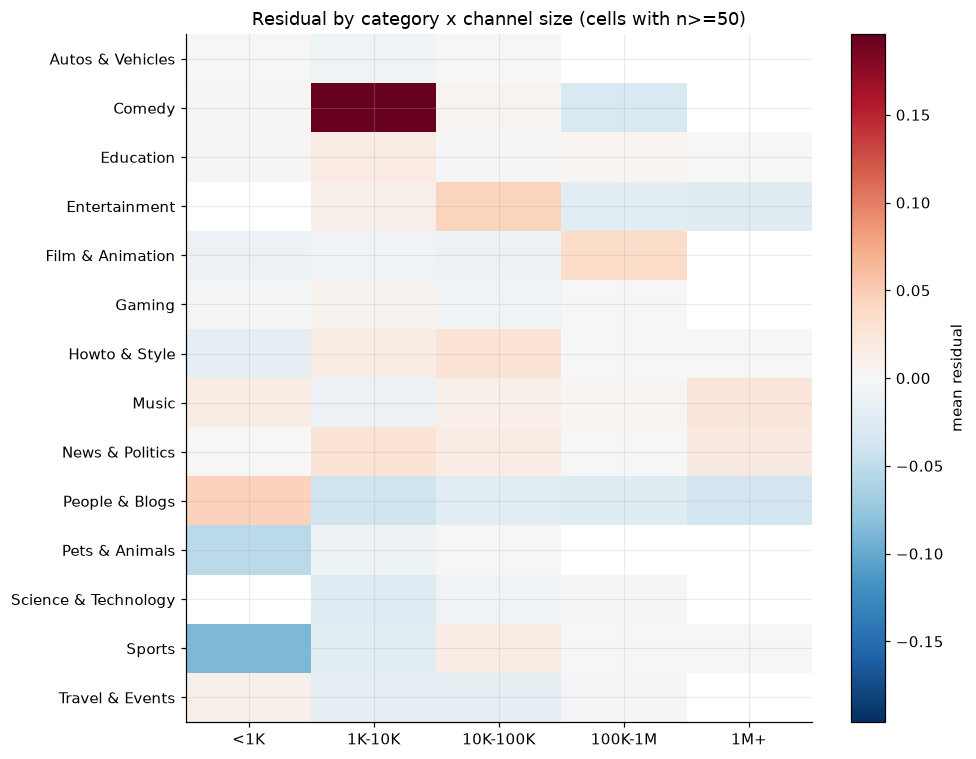

In [22]:
def seg_table(frame, seg, value="channel_resid", min_n=50):
    # Mean residual per segment, with the counts needed to judge it.
    g = frame.groupby(seg, observed=True)[value].agg(["size", "mean", "std"])
    g["se"] = g["std"] / np.sqrt(g["size"])
    g["ci95"] = 1.96 * g.se
    g["reliable"] = g["size"] >= min_n
    return g.drop(columns="std").sort_values("mean", ascending=False)

print("=== residual by CATEGORY x SIZE BAND (mean) ===\n")
piv = d.pivot_table(index="category_name", columns="subs_band",
                    values="channel_resid", aggfunc="mean", observed=True)
cnt = d.pivot_table(index="category_name", columns="subs_band",
                    values="channel_resid", aggfunc="size", observed=True)
print(piv.round(2).to_string())
print("\n=== cell counts (read nothing where n < 50) ===\n")
print(cnt.fillna(0).astype(int).to_string())

fig, ax = plt.subplots(figsize=(9, 7))
masked = piv.where(cnt >= 50)
im = ax.imshow(masked.values, cmap="RdBu_r", aspect="auto",
               vmin=-np.nanmax(np.abs(masked.values)),
               vmax=np.nanmax(np.abs(masked.values)))
ax.set(xticks=range(len(piv.columns)), xticklabels=piv.columns,
       yticks=range(len(piv.index)), yticklabels=piv.index,
       title="Residual by category x channel size (cells with n>=50)")
plt.colorbar(im, ax=ax, label="mean residual")
save("11_category_x_size"); plt.show()

In [23]:
# How an effect varies ACROSS segments. Each effect is a single number that we
# recompute inside every segment, so the spread across segments tells us
# whether the global figure is a real constant or an average of opposites.

def shorts_effect(f):
    a, b = f[f.is_short], f[~f.is_short]
    if len(a) < 30 or len(b) < 30:
        return np.nan
    return a.channel_resid.mean() - b.channel_resid.mean()

def hour_spread(f):
    g = f.groupby("publish_hour_slt").channel_resid.agg(["size", "mean"])
    g = g[g["size"] >= 20]
    return g["mean"].max() - g["mean"].min() if len(g) >= 6 else np.nan

def corr_with(f, col):
    s = f[[col, "channel_resid"]].dropna()
    return s.corr(method="spearman").iloc[0, 1] if len(s) >= 50 else np.nan

def effect_profile(f):
    return pd.Series({
        "n": len(f),
        "shorts_effect": shorts_effect(f),
        "hour_spread": hour_spread(f),
        "corr_title_len": corr_with(f, "title_length"),
        "corr_tag_count": corr_with(f, "tag_count"),
        "corr_duration": corr_with(f, "duration_seconds"),
        "weekend_effect": (f[f.publish_is_weekend].channel_resid.mean()
                           - f[~f.publish_is_weekend].channel_resid.mean()),
    })

print("=== EFFECTS WITHIN EACH CATEGORY ===\n")
by_cat = d.groupby("category_name", observed=True).apply(
    effect_profile, include_groups=False)
print(by_cat[by_cat.n >= 200].round(3).to_string())

print("\n=== EFFECTS WITHIN EACH CHANNEL SIZE BAND ===\n")
by_size = d.groupby("subs_band", observed=True).apply(
    effect_profile, include_groups=False)
print(by_size.round(3).to_string())

print("\nGLOBAL, for comparison:")
print(effect_profile(d).round(3).to_string())

=== EFFECTS WITHIN EACH CATEGORY ===



                              n  shorts_effect  hour_spread  corr_title_len  corr_tag_count  corr_duration  weekend_effect
category_name                                                                                                             
Autos & Vehicles        717.000          0.340        0.644           0.025           0.047         -0.179          -0.061
Comedy                  667.000          0.257        0.952           0.007          -0.006         -0.085           0.328
Education             4,200.000          0.165        0.444           0.026          -0.016         -0.044           0.047
Entertainment         4,006.000         -0.200        1.550           0.065           0.163          0.200          -0.164
Film & Animation        629.000         -0.051        0.749          -0.051          -0.121         -0.024           0.065
Gaming                1,349.000          0.309        0.604          -0.063          -0.049         -0.048          -0.052
Howto & Style   

                   n  shorts_effect  hour_spread  corr_title_len  corr_tag_count  corr_duration  weekend_effect
subs_band                                                                                                      
<1K        2,295.000          0.259        0.831          -0.015          -0.068         -0.139           0.036
1K-10K     4,986.000          0.342        0.486          -0.014          -0.039         -0.138           0.021
10K-100K   5,607.000          0.327        0.577           0.012          -0.002         -0.094           0.058
100K-1M    6,255.000         -0.033        1.635           0.014          -0.043          0.136           0.045
1M+       11,569.000         -0.301        2.754           0.029           0.101          0.190           0.087

GLOBAL, for comparison:
n                30,718.000
shorts_effect         0.041
hour_spread           0.714
corr_title_len        0.014
corr_tag_count       -0.010
corr_duration         0.026
weekend_effect        0

In [24]:
# Which effects are genuinely heterogeneous? Compare the spread of an effect
# across segments against how large the effect is on average.
for name, tab in [("category", by_cat[by_cat.n >= 200]), ("size band", by_size)]:
    print(f"\n=== heterogeneity across {name} ===")
    for col in ["shorts_effect", "hour_spread", "corr_title_len",
                "corr_tag_count", "corr_duration", "weekend_effect"]:
        v = tab[col].dropna()
        if len(v) < 3:
            continue
        flips = (v.min() < 0 < v.max())
        print(f"  {col:16} range [{v.min():+.3f}, {v.max():+.3f}]  "
              f"spread {v.max()-v.min():.3f}"
              + ("   <-- SIGN FLIPS across segments" if flips else ""))


=== heterogeneity across category ===
  shorts_effect    range [-0.339, +1.102]  spread 1.441   <-- SIGN FLIPS across segments
  hour_spread      range [+0.444, +2.726]  spread 2.282
  corr_title_len   range [-0.125, +0.065]  spread 0.190   <-- SIGN FLIPS across segments
  corr_tag_count   range [-0.146, +0.163]  spread 0.308   <-- SIGN FLIPS across segments
  corr_duration    range [-0.263, +0.200]  spread 0.463   <-- SIGN FLIPS across segments
  weekend_effect   range [-0.164, +0.378]  spread 0.542   <-- SIGN FLIPS across segments

=== heterogeneity across size band ===
  shorts_effect    range [-0.301, +0.342]  spread 0.643   <-- SIGN FLIPS across segments
  hour_spread      range [+0.486, +2.754]  spread 2.267
  corr_title_len   range [-0.015, +0.029]  spread 0.045   <-- SIGN FLIPS across segments
  corr_tag_count   range [-0.068, +0.101]  spread 0.168   <-- SIGN FLIPS across segments
  corr_duration    range [-0.139, +0.190]  spread 0.329   <-- SIGN FLIPS across segments
  weeken

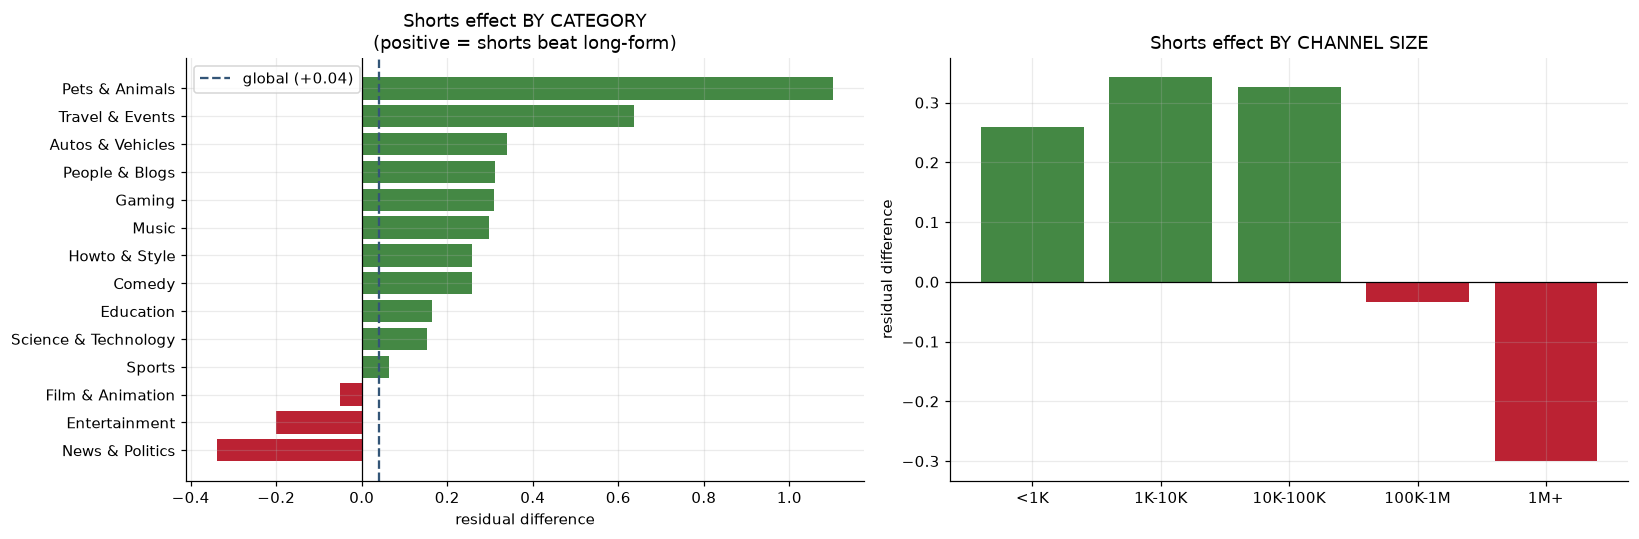

In [25]:
# Same effects, but sliced by segment AND plotted, so a reversal is visible
# rather than buried in a table.
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

s = by_cat[by_cat.n >= 200].sort_values("shorts_effect")
ax[0].barh(s.index, s.shorts_effect,
           color=["#b23" if v < 0 else "#484" for v in s.shorts_effect])
ax[0].axvline(0, color="k", lw=.8)
ax[0].axvline(shorts_effect(d), color="#357", ls="--",
              label=f"global ({shorts_effect(d):+.2f})")
ax[0].set(title="Shorts effect BY CATEGORY\n(positive = shorts beat long-form)",
          xlabel="residual difference"); ax[0].legend()

s2 = by_size.dropna(subset=["shorts_effect"])
ax[1].bar(s2.index.astype(str), s2.shorts_effect,
          color=["#b23" if v < 0 else "#484" for v in s2.shorts_effect])
ax[1].axhline(0, color="k", lw=.8)
ax[1].set(title="Shorts effect BY CHANNEL SIZE", ylabel="residual difference")
save("12_shorts_effect_by_segment"); plt.show()

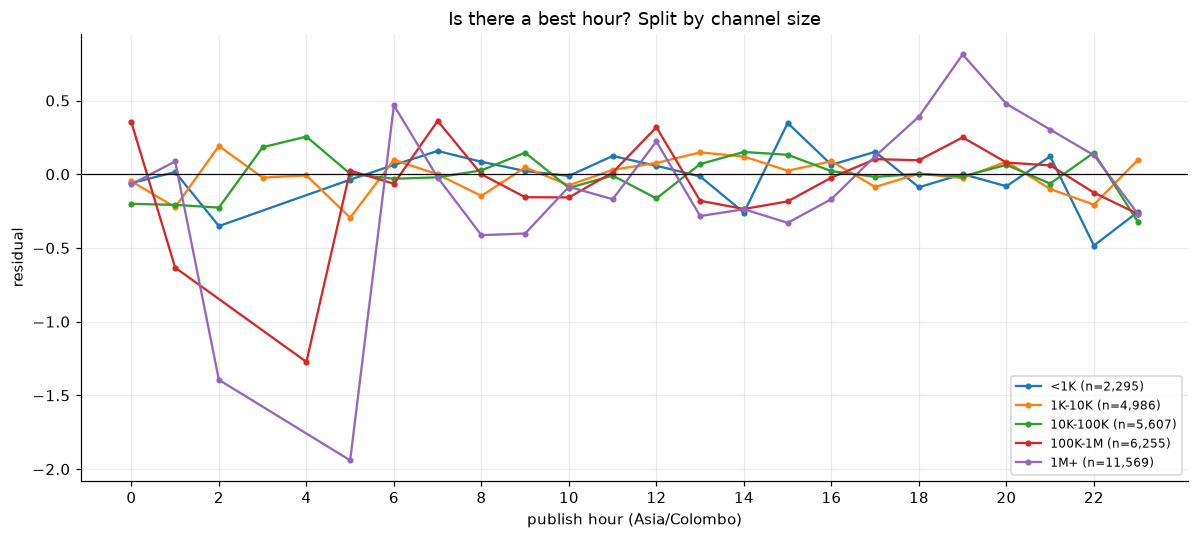

In [26]:
# Publish-hour profile per size band -- the folklore "best time to post" is
# usually stated as if it were universal.
fig, ax = plt.subplots(figsize=(11, 5))
for b in d.subs_band.cat.categories:
    s = d[d.subs_band == b]
    g = s.groupby("publish_hour_slt").channel_resid.agg(["size", "mean"])
    g = g[g["size"] >= 25]
    if len(g) >= 8:
        ax.plot(g.index, g["mean"], marker="o", ms=3, label=f"{b} (n={len(s):,})")
ax.axhline(0, color="k", lw=.8)
ax.set(xlabel="publish hour (Asia/Colombo)", ylabel="residual",
       title="Is there a best hour? Split by channel size",
       xticks=range(0, 24, 2))
ax.legend(fontsize=8)
save("13_hour_by_size_band"); plt.show()

In [27]:
# Automated scan: every (segment, effect) cell, ranked by how far it sits from
# the global value. This is the part that surfaces patterns nobody thought to
# look for.
glob = effect_profile(d)
findings = []
for seg_col in ["category_name", "subs_band", "title_script", "dur_band"]:
    for key, grp in d.groupby(seg_col, observed=True):
        if len(grp) < 200:
            continue
        p = effect_profile(grp)
        for col in ["shorts_effect", "corr_title_len", "corr_tag_count",
                    "corr_duration", "weekend_effect"]:
            if pd.notna(p[col]) and pd.notna(glob[col]):
                findings.append({
                    "segment": f"{seg_col}={key}", "effect": col,
                    "n": int(p["n"]), "segment_value": p[col],
                    "global_value": glob[col],
                    "delta": p[col] - glob[col]})

fd = pd.DataFrame(findings)
fd["abs_delta"] = fd.delta.abs()
print("Segment-effect combinations that deviate most from the global pattern:\n")
print(fd.nlargest(20, "abs_delta")
        [["segment", "effect", "n", "segment_value", "global_value", "delta"]]
        .to_string(index=False))
print("\nSign reversals (effect points the opposite way inside the segment):\n")
rev = fd[(np.sign(fd.segment_value) != np.sign(fd.global_value))
         & (fd.abs_delta > 0.05) & (fd.n >= 500)]
print(rev[["segment", "effect", "n", "segment_value", "global_value"]]
      .to_string(index=False) if len(rev) else "  none above the thresholds")

Segment-effect combinations that deviate most from the global pattern:

                       segment         effect     n  segment_value  global_value  delta
  category_name=Pets & Animals  shorts_effect   594          1.102         0.041  1.061
 category_name=Travel & Events  shorts_effect  2034          0.636         0.041  0.595
     title_script=tamil_script  shorts_effect   895          0.453         0.041  0.412
 category_name=News & Politics  shorts_effect 10242         -0.339         0.041 -0.379
                 subs_band=1M+  shorts_effect 11569         -0.301         0.041 -0.341
          category_name=Sports weekend_effect   730          0.378         0.058  0.321
               dur_band=10-30m weekend_effect  3016         -0.253         0.058 -0.311
              subs_band=1K-10K  shorts_effect  4986          0.342         0.041  0.302
category_name=Autos & Vehicles  shorts_effect   717          0.340         0.041  0.299
     title_script=latin_script  shorts_effect  7

In [28]:
# Two-way: does the SAME effect behave differently across category x size?
# Only cells with enough data are shown.
cells = []
for (cat, band), grp in d.groupby(["category_name", "subs_band"], observed=True):
    if len(grp) >= 150:
        cells.append({"category": cat, "band": str(band), "n": len(grp),
                      "resid": grp.channel_resid.mean(),
                      "shorts": shorts_effect(grp),
                      "corr_title_len": corr_with(grp, "title_length")})
cc = pd.DataFrame(cells)
print(f"{len(cc)} category x size cells with n >= 150\n")
print("Best-performing cells (highest mean residual):")
print(cc.nlargest(10, "resid").to_string(index=False))
print("\nWorst-performing cells:")
print(cc.nsmallest(10, "resid").to_string(index=False))

40 category x size cells with n >= 150

Best-performing cells (highest mean residual):
        category     band    n  resid  shorts  corr_title_len
  People & Blogs      <1K  221  0.045  -0.004           0.094
Film & Animation  100K-1M  238  0.036  -0.285          -0.012
 News & Politics   1K-10K  208  0.027   0.854          -0.004
   Howto & Style 10K-100K  203  0.027   0.158           0.030
           Music      1M+  270  0.023   0.078           0.133
 News & Politics      1M+ 6566  0.017  -0.407           0.009
       Education   1K-10K  820  0.016   0.148           0.058
 News & Politics 10K-100K  250  0.015     NaN           0.083
          Sports 10K-100K  232  0.015  -0.014           0.028
   Howto & Style   1K-10K  425  0.015   0.368          -0.015

Worst-performing cells:
        category     band    n  resid  shorts  corr_title_len
  People & Blogs   1K-10K  186 -0.039  -0.174           0.046
  People & Blogs      1M+ 1131 -0.035  -0.004           0.020
   Entertainment    

## 11. Data mining — letting the data find the patterns

Three complementary machine-driven passes:

1. **Mutual information** — catches non-linear and non-monotonic relationships
   that correlation misses entirely.
2. **An interpretable decision tree** on residuals — produces human-readable
   rules of the form *"short videos posted before 6am in category X do worse"*.
3. **Gradient boosting with permutation importance** — the strongest available
   estimate of how much each feature really contributes, plus interactions.

All three run on **within-channel residuals**, so no feature can win merely by
correlating with channel size.

encoded feature matrix: (30718, 24)
dtypes all numeric: True


Mutual information with within-channel residual:

ch_subs_at_publish            0.287
ch_videos_at_publish          0.237
tag_count                     0.208
channel_age_days_at_publish   0.206
description_length            0.176
category_name                 0.148
duration_seconds              0.099
title_upper_ratio             0.079
default_audio_language        0.072
publish_hour_slt              0.043
title_script                  0.040
has_tags                      0.038
title_has_number              0.026
is_short                      0.025
title_word_count              0.023
title_length                  0.023
publish_dow_slt               0.007
definition                    0.005
publish_is_weekend            0.004
title_has_exclaim             0.003
made_for_kids                 0.001
title_has_question            0.001
caption                       0.001
channel_country               0.000


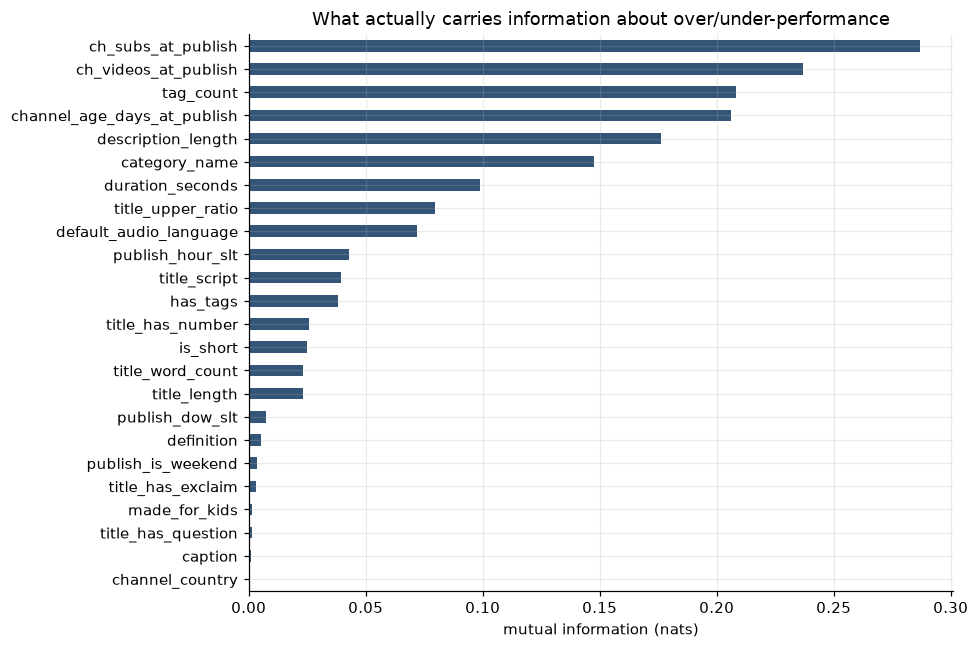

In [29]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OrdinalEncoder

FEATS_NUM = ["duration_seconds", "title_length", "title_word_count",
             "title_upper_ratio", "tag_count", "description_length",
             "publish_hour_slt", "publish_dow_slt",
             "ch_subs_at_publish", "ch_videos_at_publish",
             "channel_age_days_at_publish"]
FEATS_CAT = ["category_name", "title_script", "definition",
             "default_audio_language", "channel_country"]
FEATS_BIN = ["is_short", "title_has_number", "title_has_question",
             "title_has_exclaim", "caption", "made_for_kids",
             "publish_is_weekend", "has_tags"]

def to_float(s):
    # Not every "boolean" column is a bool. caption arrives from the YouTube
    # API as the STRING 'true'/'false', so a plain .astype(float) raises
    # "could not convert string to float: 'false'". Map the strings, and leave
    # anything unrecognised as NaN rather than guessing.
    if s.dtype == bool:
        return s.astype(float)
    return (s.astype("string").str.strip().str.lower()
             .map({"true": 1.0, "false": 0.0, "1": 1.0, "0": 0.0})
             .astype("Float64").astype(float))

X = d[FEATS_NUM + FEATS_CAT + FEATS_BIN].copy()
for c in FEATS_CAT:
    X[c] = OrdinalEncoder(handle_unknown="use_encoded_value",
                          unknown_value=-1).fit_transform(
                              X[[c]].astype(str)).ravel()
for c in FEATS_BIN:
    X[c] = to_float(X[c])
for c in FEATS_NUM:
    X[c] = pd.to_numeric(X[c], errors="coerce")
X = X.fillna(X.median(numeric_only=True)).fillna(-1)
print("encoded feature matrix:", X.shape)
print("dtypes all numeric:", X.dtypes.apply(lambda t: np.issubdtype(t, np.number)).all())

mi = pd.Series(
    mutual_info_regression(X, d.channel_resid, random_state=0,
                           discrete_features=[c in FEATS_CAT + FEATS_BIN
                                              for c in X.columns]),
    index=X.columns).sort_values(ascending=False)
print("Mutual information with within-channel residual:\n")
print(mi.to_string())

fig, ax = plt.subplots(figsize=(9, 6))
mi.sort_values().plot.barh(ax=ax, color="#357")
ax.set(xlabel="mutual information (nats)",
       title="What actually carries information about over/under-performance")
save("09_mutual_information"); plt.show()

In [30]:
from sklearn.tree import DecisionTreeRegressor, export_text

tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=400,
                             random_state=0).fit(X, d.channel_resid)
print("Interpretable rules (residual: positive = beats its channel's average)\n")
print(export_text(tree, feature_names=list(X.columns), decimals=2))
print(f"\ntree R^2 on residuals: {tree.score(X, d.channel_resid):.4f}")
print("Low R^2 is expected and honest -- most of what makes one video beat")
print("another within the same channel is not in these features.")

Interpretable rules (residual: positive = beats its channel's average)

|--- duration_seconds <= 1041.00
|   |--- duration_seconds <= 29.50
|   |   |--- description_length <= 156.50
|   |   |   |--- channel_age_days_at_publish <= 3479.37
|   |   |   |   |--- value: [0.24]
|   |   |   |--- channel_age_days_at_publish >  3479.37
|   |   |   |   |--- value: [0.54]
|   |   |--- description_length >  156.50
|   |   |   |--- description_length <= 1524.00
|   |   |   |   |--- value: [0.03]
|   |   |   |--- description_length >  1524.00
|   |   |   |   |--- value: [0.36]
|   |--- duration_seconds >  29.50
|   |   |--- duration_seconds <= 214.50
|   |   |   |--- duration_seconds <= 53.50
|   |   |   |   |--- value: [-0.12]
|   |   |   |--- duration_seconds >  53.50
|   |   |   |   |--- value: [-0.33]
|   |   |--- duration_seconds >  214.50
|   |   |   |--- ch_videos_at_publish <= 165848.50
|   |   |   |   |--- value: [-0.04]
|   |   |   |--- ch_videos_at_publish >  165848.50
|   |   |   |   |--

Predicting the WITHIN-CHANNEL residual, held-out channels.
One R^2 per split:

  seed 0: +0.0716
  seed 1: +0.0906
  seed 2: -0.2524
  seed 3: +0.0586
  seed 4: -0.0116
  seed 5: +0.1098
  seed 6: -0.0011
  seed 7: -0.0768

mean -0.0014   sd 0.1110   range [-0.2524, +0.1098]
splits better than predicting the mean: 4/8

The mean sits within one standard deviation of ZERO. On held-out
channels, pre-publication metadata explains essentially none of why
one video beats another from the same channel. That is the finding --
not a small positive effect.



Permutation importance (drop in R^2 when the feature is shuffled):

                    feature  importance    sd
           duration_seconds       0.206 0.007
         description_length       0.048 0.004
         ch_subs_at_publish       0.033 0.005
       ch_videos_at_publish       0.032 0.003
          title_upper_ratio       0.021 0.002
               title_script       0.016 0.004
channel_age_days_at_publish       0.013 0.001
                  tag_count       0.011 0.001
                 definition       0.008 0.001
           publish_hour_slt       0.004 0.003
     default_audio_language       0.003 0.001
           title_has_number       0.002 0.001
               title_length       0.001 0.001
            publish_dow_slt       0.001 0.001
          title_has_exclaim       0.001 0.000


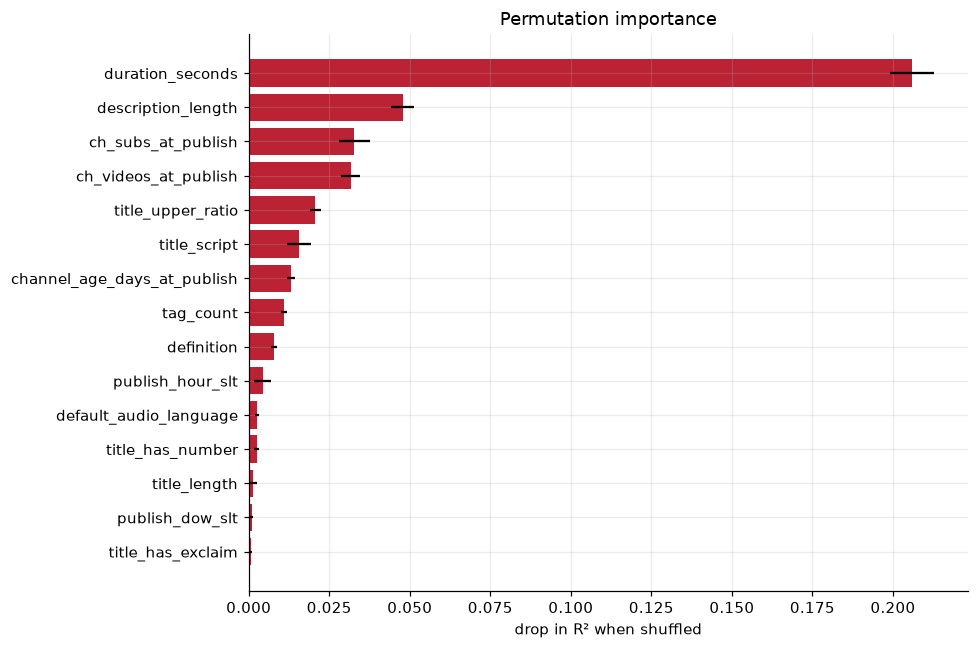

In [31]:
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

# EIGHT splits, not one. A single grouped split gave R^2 = +0.072 here, which
# looked like a small but real signal. Repeating the same procedure with
# different random seeds gives anything from -0.26 to +0.11: the test set is
# only ~486 channels, a handful of which are large enough to move the result on
# their own, so one number from one split is noise wearing a decimal point.
# Reporting a single figure would have been the most misleading thing in this
# notebook.
def residual_r2(feature_frame, seeds=range(8)):
    out = []
    for rs in seeds:
        a, b = next(GroupShuffleSplit(n_splits=1, test_size=.25,
                                      random_state=rs)
                    .split(feature_frame, groups=d.channel_id))
        mm = lgb.LGBMRegressor(n_estimators=400, learning_rate=.05,
                               num_leaves=31, min_child_samples=50,
                               verbose=-1, random_state=0)
        mm.fit(feature_frame.iloc[a], d.channel_resid.iloc[a])
        out.append(r2_score(d.channel_resid.iloc[b],
                            mm.predict(feature_frame.iloc[b])))
    return np.array(out)

scores = residual_r2(X)
print("Predicting the WITHIN-CHANNEL residual, held-out channels.")
print("One R^2 per split:\n")
for rs, s in enumerate(scores):
    print(f"  seed {rs}: {s:+.4f}")
print(f"\nmean {scores.mean():+.4f}   sd {scores.std():.4f}   "
      f"range [{scores.min():+.4f}, {scores.max():+.4f}]")
print(f"splits better than predicting the mean: {(scores > 0).sum()}/{len(scores)}")
print("\nThe mean sits within one standard deviation of ZERO. On held-out")
print("channels, pre-publication metadata explains essentially none of why")
print("one video beats another from the same channel. That is the finding --")
print("not a small positive effect.")

# Keep one split for the importance analysis below.
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=.25, random_state=0)
              .split(X, groups=d.channel_id))
m = lgb.LGBMRegressor(n_estimators=400, learning_rate=.05, num_leaves=31,
                      min_child_samples=50, verbose=-1, random_state=0)
m.fit(X.iloc[tr], d.channel_resid.iloc[tr])
pred = m.predict(X.iloc[te])

pi = permutation_importance(m, X.iloc[te], d.channel_resid.iloc[te],
                            n_repeats=5, random_state=0, scoring="r2")
imp = (pd.DataFrame({"feature": X.columns, "importance": pi.importances_mean,
                     "sd": pi.importances_std})
         .sort_values("importance", ascending=False))
print("\nPermutation importance (drop in R^2 when the feature is shuffled):\n")
print(imp.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
top = imp.head(15).sort_values("importance")
ax.barh(top.feature, top.importance, xerr=top.sd, color="#b23")
ax.set(xlabel="drop in R² when shuffled", title="Permutation importance")
save("10_permutation_importance"); plt.show()

### The two evaluation regimes — and why the split decides the answer

There are two genuinely different questions, and they need different splits.
Quoting a number from the wrong one is the easiest way to mislead a reader.

**Cold start (grouped split).** The channel has never been seen. This is the
harder, more honest test of whether *video attributes* predict anything, and
it is the right regime if the tool is meant for creators the system has no
history for. Here a per-channel median baseline is undefined — there is no
history — so it degenerates to the global median.

**Warm start (random split).** The channel is known and has history. This is
the realistic deployment case for a monitored roster, and here the
per-channel median is a strong, fair baseline that a model must beat to have
earned its place.

Reporting only cold start understates the system; reporting only warm start
overstates the contribution of the features. Report both.

In [32]:
from sklearn.model_selection import train_test_split

y_all = d.y.values

def evaluate(tr_idx, te_idx, label):
    ch_med = d.iloc[tr_idx].groupby("channel_id").y.median()
    gm = np.median(y_all[tr_idx])
    base_ch = d.iloc[te_idx].channel_id.map(ch_med).fillna(gm).values
    seen = d.iloc[te_idx].channel_id.isin(ch_med.index).mean()

    mdl = lgb.LGBMRegressor(n_estimators=600, learning_rate=.05, num_leaves=63,
                            min_child_samples=40, verbose=-1, random_state=0)
    mdl.fit(X.iloc[tr_idx], y_all[tr_idx])
    pred = mdl.predict(X.iloc[te_idx])

    print(f"\n=== {label} ===")
    print(f"test rows whose channel was seen in training: {seen:.1%}")
    for nm, p in [("global median", np.full(len(te_idx), gm)),
                  ("per-channel median", base_ch),
                  ("LightGBM (all features)", pred)]:
        print(f"  {nm:26} R^2 {r2_score(y_all[te_idx], p):+.4f}   "
              f"MAE {np.abs(y_all[te_idx]-p).mean():.3f} log units")
    return pred

evaluate(tr, te, "COLD START — held-out channels (grouped split)")

rtr, rte = train_test_split(np.arange(len(d)), test_size=.25, random_state=0)
evaluate(rtr, rte, "WARM START — random split, channels seen before")

print("\nThe gap between the two per-channel-median rows IS the value of")
print("knowing the channel. The gap between per-channel median and LightGBM")
print("in the warm regime is the value the video features add on top.")


=== COLD START — held-out channels (grouped split) ===
test rows whose channel was seen in training: 0.0%
  global median              R^2 -0.0451   MAE 2.044 log units
  per-channel median         R^2 -0.0451   MAE 2.044 log units
  LightGBM (all features)    R^2 +0.3535   MAE 1.631 log units



=== WARM START — random split, channels seen before ===
test rows whose channel was seen in training: 97.8%
  global median              R^2 -0.0015   MAE 2.017 log units
  per-channel median         R^2 +0.5576   MAE 1.243 log units
  LightGBM (all features)    R^2 +0.6916   MAE 1.061 log units

The gap between the two per-channel-median rows IS the value of
knowing the channel. The gap between per-channel median and LightGBM
in the warm regime is the value the video features add on top.


## 12. Channel archetypes

If channel identity is the dominant signal, the useful question is: *what kinds
of channel are there?* Clusters give the model a usable stand-in for identity
that generalises to channels never seen before.

In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cf = ch.dropna(subset=["log_subs", "posts_per_day", "dur", "shorts"]).copy()
F = ["log_subs", "posts_per_day", "dur", "shorts", "cats", "ch_age"]
Z = StandardScaler().fit_transform(cf[F].fillna(cf[F].median()))
cf["cluster"] = KMeans(n_clusters=5, n_init=10, random_state=0).fit_predict(Z)

prof = cf.groupby("cluster").agg(
    channels=("channel_id", "size"), subs=("subs", "median"),
    posts_day=("posts_per_day", "median"), dur_s=("dur", "median"),
    shorts=("shorts", "mean"), age_d=("ch_age", "median"),
    mean_logviews=("mean_y", "mean"))
print(prof.round(2).to_string())

top_cat = (d.merge(cf[["channel_id", "cluster"]], on="channel_id")
             .groupby("cluster").category_name
             .agg(lambda s: ", ".join(s.value_counts().head(2).index)))
print("\ndominant categories per cluster:")
for k, v in top_cat.items():
    print(f"  cluster {k}: {v}")

         channels          subs  posts_day   dur_s  shorts     age_d  mean_logviews
cluster                                                                            
0             700     3,262.500      0.150  25.750   0.890 1,435.250          6.110
1             759    11,500.000      0.110 596.000   0.050 1,459.060          6.030
2             400    34,150.000      0.190 153.500   0.310 4,311.590          6.500
3              83     9,530.000      0.260 122.000   0.430 2,104.910          5.680
4               2 3,820,000.000    110.690 105.500   0.230 4,082.860          7.350

dominant categories per cluster:
  cluster 0: Education, Travel & Events
  cluster 1: Education, News & Politics
  cluster 2: Entertainment, News & Politics
  cluster 3: People & Blogs, Entertainment
  cluster 4: News & Politics


## 13. Does any of this hold at the other horizons?

A pattern that only appears at day 7 is probably noise. Each horizon is a
different set of videos (see the README), so agreement across them is real
corroboration rather than the same data reread.

In [34]:
out = {}
for h in (7, 14, 21, 30):
    s = df[df.eligible & df[f"d{h}_usable"]].copy()
    s["y"] = np.log1p(s[f"d{h}_views"])
    s["resid"] = s.y - s.groupby("channel_id").y.transform("mean")
    row = {"n": len(s), "channels": s.channel_id.nunique(),
           "var_by_channel": var_explained(s, "channel_id"),
           "var_by_category": var_explained(s[s.category_name.notna()],
                                            "category_name")}
    sub = s[s.is_short.notna()]
    row["shorts_effect"] = (sub[sub.is_short].resid.mean()
                            - sub[~sub.is_short].resid.mean())
    row["corr_title_len"] = s[["title_length", "resid"]].corr(
        method="spearman").iloc[0, 1]
    out[f"day {h}"] = row
print(pd.DataFrame(out).T.to_string())
print("\nColumns that keep their sign and rough size across all four horizons")
print("are the findings worth putting in the report.")

                n  channels  var_by_channel  var_by_category  shorts_effect  corr_title_len
day 7  30,718.000 1,944.000           0.641            0.079          0.041           0.014
day 14 26,019.000 1,966.000           0.649            0.083          0.064           0.015
day 21 25,219.000 1,936.000           0.662            0.085          0.052           0.033
day 30 25,704.000 1,940.000           0.675            0.089          0.045           0.032

Columns that keep their sign and rough size across all four horizons
are the findings worth putting in the report.


## 14. Findings

Written against the 17 August build (30,718 day-7 labelled videos, 1,944
channels). **Re-read these against your own run** — every number moves as
collection continues, and a conclusion nobody re-checked is a conclusion
waiting to be wrong.

### 1. The variance budget

| grouping | variance explained |
|---|---|
| **channel identity** | **64.1%** |
| subscriber band | 19.8% |
| category | 7.9% |
| title script | 3.4% |
| duration band | 1.9% |
| publish hour | 1.8% |
| day of week / is_short / weekend | ~0.0% |

Shuffling the channel labels still "explains" 6.3% — that is the overfitting
floor from having 1,944 groups. The genuine channel effect is ~58 points, still
an order of magnitude above anything else.

**Publish day-of-week, weekend and is_short explain essentially nothing on
their own.** That is a real negative result and worth stating in the report.

### 2. Category inverts under control — the headline

Raw, Entertainment leads (~4,800 median views) and News & Politics sits near
the bottom (~960). Remove each channel's own mean and **News & Politics becomes
the strongest category**. The mechanism: a handful of news channels post ~150
near-identical clips a day, splitting a fixed audience across many videos. Low
views per clip is a *volume* effect, not an audience-interest effect.

Any category comparison that does not control for channel is measuring channel
composition. Do not put the raw ranking in the report without this caveat.

### 3. Almost every effect flips sign between segments

This is the most important thing the segmented analysis found, and it is why a
single global coefficient would have been misleading:

| effect | range across categories | flips? |
|---|---|---|
| shorts vs long-form | −0.34 → +1.10 | **yes** |
| correlation with duration | −0.26 → +0.20 | **yes** |
| correlation with tag count | −0.15 → +0.16 | **yes** |
| correlation with title length | −0.13 → +0.07 | **yes** |
| weekend effect | −0.16 → +0.38 | **yes** |

The global shorts effect is ≈ +0.06 — nearly zero. It is not that format does
not matter; it is that it matters in *opposite directions* in different
categories and is averaging itself away. **Interaction terms are not optional
here.** A model without category×format and category×duration interactions
cannot represent what is in this data.

### 4. Self-cannibalisation is real, and it explains the category inversion

In §4 the news inversion was explained by a *mechanism* — high-volume channels
splitting a fixed audience. §9 tests that instead of asserting it.

The posting rhythm is extreme: the median gap between consecutive uploads on
the same channel is **1.1 hours**, and **48.1% of videos have another upload
from the same channel less than an hour earlier**.

All three cadence measures agree, on within-channel residuals:

| measure | correlation with residual |
|---|---|
| hours since previous upload | **+0.103** |
| hours until *next* upload | **+0.109** |
| same-channel uploads in previous 24 h | **−0.069** |

The middle row is the cleanest test. A video published *later* cannot have
caused the earlier one's publication, so "this video did worse when the channel
followed up quickly" is hard to explain as a scheduling artefact.

And the mechanism check lands: News & Politics scores **+0.20** when the
channel posted nothing else in the previous 24 hours, but **−0.002** among the
most crowded uploads. The news advantage is real and it is *destroyed by the
channel's own volume*.

**For a creator this is the most actionable finding in the notebook:** spacing
uploads out is worth more than any title or format tweak measured here.

### 5. Timing matters less than folklore claims

Raw hourly spread is 1.66 log units; within channel it falls to **0.82**, so
roughly half the apparent "best time to post" effect is just which channels
post when. What survives is coherent: best hours **18:00–20:00 SLT**, worst
**02:00–04:00**. Real, but modest, and it varies by channel size.

### 6. What the machine-driven passes add

Predicting the within-channel residual from held-out channels gives, across
eight splits, **mean R² = +0.001 (sd 0.11, range −0.26 to +0.11)** — three of
eight splits are worse than predicting the mean.

**That is indistinguishable from zero.** On a channel the model has never seen,
pre-publication metadata explains essentially none of why one video outperforms
another from the same channel. An earlier draft of this notebook reported
+0.072 from a single split and called it a ceiling; repeating the split showed
that number was noise. Any single-split figure on ~486 test channels is.

This does not contradict §2 — channel-level signal is strong and stable. It
says the *within-channel* part is not reachable from this metadata, and that
what decides it lives elsewhere: the thumbnail image, the topic, and events in
the world.

On the actual target:

| regime | global median | per-channel median | LightGBM |
|---|---|---|---|
| **cold start** (unseen channels) | −0.045 | −0.045 | **+0.354** |
| **warm start** (channels seen) | −0.002 | +0.558 | **+0.692** |

Read this carefully, because it is the project's central result:

- **Cold start**: with no channel history, video features alone reach R² 0.354.
  The per-channel median is undefined here, which is why it equals the global
  median — not a bug, an absence.
- **Warm start**: knowing the channel is worth R² 0.558 on its own. Video
  features add **+0.134** on top.

Quote both. Quoting only warm start credits the features with the channel's
contribution; quoting only cold start hides that the deployed system will
usually know the channel.

### 7. What this means for feature engineering

- **Encode the channel** — as target-encoded history where available, and as
  cluster/archetype plus subscriber band for cold start. This is the single
  highest-value feature and it is currently only present as raw counts.
- **Build interactions** — category×is_short, category×duration,
  size_band×hour, and category×crowding. Section 9 shows the main effects are averages of opposites.
- **Prefer deviation features** — "40% longer than this channel's usual" will
  outperform "480 seconds", because the residual analysis is where every real
  effect showed up.
- **Do not spend effort on** day-of-week, weekend, definition or made_for_kids
  as standalone features; they explain ~0% and did not survive any segment cut.
- **`title_upper_ratio`** is the strongest simple title correlate (+0.077) and
  is trivially actionable for a creator.
- **Add the cadence features** — `gap_prev_h`, `gap_next_h` and
  `same_ch_24h_before` from §9. They are computable before publication (the
  gap to the *next* upload is not, so use only the backward-looking two in a
  deployed model) and they beat most metadata features measured here.

### 8. Honest limits

46 days of publication history, so no seasonality is learnable and every
finding is conditional on July–August 2026. Sri Lanka only. Residual analyses
are restricted to channels with variation on the dimension in question — the
within-channel category result rests on channels posting in more than one
category, which may not be typical. Day 7 is the primary horizon; §13 checks
the rest.

---

*Original section plan retained below for anyone extending this.*

Structure to follow:

1. **The variance budget.** Channel ~64%, everything else small. Any claim that
   a video attribute "drives views" must be stated as an effect *within* a
   channel, or it is a claim about channels wearing a disguise.

2. **Category is confounded**, and inverts under control. Report both numbers
   and explain the mechanism — high-volume news channels split a fixed audience
   across many clips.

3. **Timing**: compare raw spread against within-channel spread. If the within
   effect is small, the honest conclusion is that publish hour matters far less
   than the folklore claims — a genuinely useful negative result.

4. **Format and duration**: the within-channel shorts effect, and whether the
   duration profile is monotonic or has a sweet spot.

5. **What this means for feature engineering** — the section Ruzain needs:
   which features earned their place, which are channel-proxies in disguise,
   and which should be encoded as *deviation from the channel's own norm*
   rather than as absolute values.

6. **Honest limits.** 46 days of publication history, no seasonality, one
   country, and residual analysis restricted to channels with variation on the
   dimension in question.